In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import torch

import sys
import os
sys.path.append(os.path.abspath("../../"))
from QNeuralForecast.dlinear import QDLinear
from QNeuralForecast.patchtst import QPatchTST
from QNeuralForecast.timesnet import QTimesNet
from QNeuralForecast.nhits import QNHITS
from neuralforecast.models import DLinear, NHITS, PatchTST, TimesNet

from neuralforecast import NeuralForecast
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.tensorboard import SummaryWriter
from neuralforecast.losses.numpy import mae, mse, rmse, mape, smape, mase


def set_global_seed(seed: int):
    """Fix all global random sources for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


In [40]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)
df = df.sort_values(["Store", "Date"])

delta_days = (max(df["Date"]) - min(df["Date"])).days
train_days = int(delta_days * 0.8)
split_date = min(df["Date"]) + np.timedelta64(train_days,"D")

split_date = "2015-01-01"
train_df = df[df["Date"] < split_date].copy()
test_df  = df[df["Date"] >= split_date].copy()

# Drop stores whose training history is too short for the model to create a
# valid internal train/val split.  Minimum: INPUT_SIZE + 2 * HORIZON = 600 days.
# (Using max INPUT_SIZE=400 and HORIZON=100 from the search space.)
MIN_TRAIN_LEN = 400 + 2 * 60  # = 600

store_lengths = train_df.groupby("Store")["Date"].count()
valid_stores  = store_lengths[store_lengths >= MIN_TRAIN_LEN].index

n_dropped = len(store_lengths) - len(valid_stores)
print(f"Stores dropped (too short): {n_dropped}  |  Stores kept: {len(valid_stores)}")

train_df = train_df[train_df["Store"].isin(valid_stores)].copy()
test_df  = test_df [test_df ["Store"].isin(valid_stores)].copy()


Stores dropped (too short): 183  |  Stores kept: 932


In [61]:
HORIZON = 60
model_classes = [QDLinear,DLinear]
#models_classes = [DLinear, QDLinear, NHITS, QNHITS, PatchTST, QPatchTST, TimesNet, QTimesNet]

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# --- Hyperparameter search space ---
HYPERPARAM_GRID = {
    "input_size":    [100, 200, 400],
    "max_steps":     [50, 100, 300],
    "learning_rate": (1e-4, 1e-1),   # log-uniform range
    "scaler_type":   ["standard", "robust", "minmax", "identity"],
}

def objective(trial):
    input_size    = trial.suggest_categorical("input_size",    HYPERPARAM_GRID["input_size"])
    max_steps     = trial.suggest_categorical("max_steps",     HYPERPARAM_GRID["max_steps"])
    learning_rate = trial.suggest_float("learning_rate", *HYPERPARAM_GRID["learning_rate"], log=True)
    scaler_type   = trial.suggest_categorical("scaler_type",   HYPERPARAM_GRID["scaler_type"])

    trial_models = [
        cls(
            h=HORIZON,
            input_size=input_size,
            max_steps=max_steps,
            learning_rate=learning_rate,
            scaler_type=scaler_type,
            start_padding_enabled=True,
            # Each trial gets its own version folder: lightning_logs/hpo/<ModelName>/version_<trial>
            **{"logger": TensorBoardLogger("lightning_logs/hpo", name=cls.__name__,
                                           version=trial.number)},
        )
        for cls in model_classes
    ]

    nf_trial = NeuralForecast(models=trial_models, freq="D")
    cv = nf_trial.cross_validation(
        train_df, n_windows=4, step_size=100,
        verbose=False, refit=False,
        id_col="Store", time_col="Date", target_col="Sales"
    )

    model_cols = [c for c in cv.columns if c not in ["Store", "Date", "Sales", "cutoff"]]
    avg_mae = float(np.mean([mae(cv["Sales"].values, cv[m].values) for m in model_cols]))
    return avg_mae

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="rossmann_hpo",
)
study.optimize(objective, n_trials=20, n_jobs=1, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest CV MAE : {study.best_value:.4f}")
print(f"Best params : {best_params}")


Best CV MAE : 1845.0987
Best params : {'input_size': 200, 'max_steps': 50, 'learning_rate': 0.00045060522797368694, 'scaler_type': 'standard'}

 number       value  params_input_size  params_max_steps  params_learning_rate params_scaler_type
     11 1845.098673                200                50              0.000451           standard
     10 1848.897759                200                50              0.000490           standard
      0 1849.068606                200                50              0.000149           standard
     16 1855.788172                200               100              0.000292           standard
      6 1856.113012                200                50              0.000104           standard
     12 1874.621326                200                50              0.000695           standard
      5 1979.103287                100               300              0.000652           standard
     17 1980.205734                200                50              0.

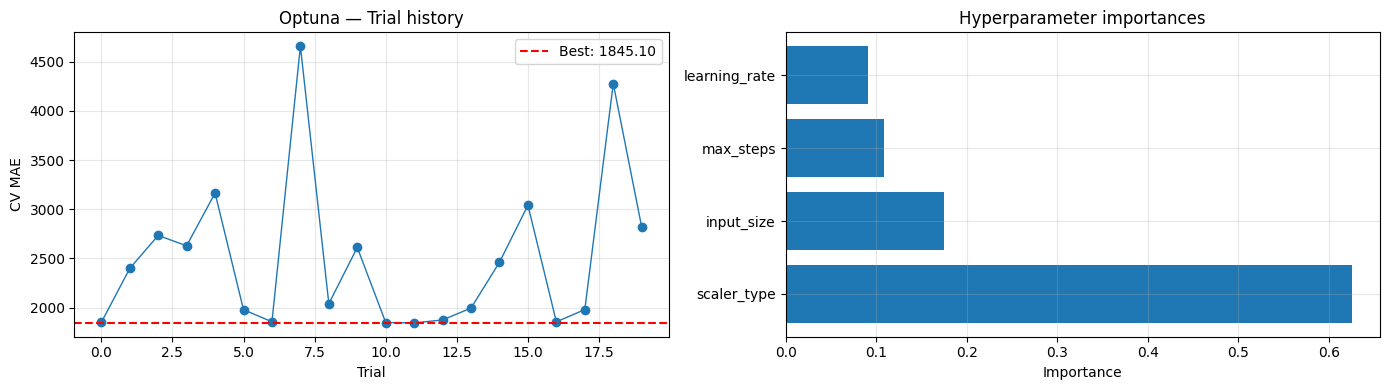

In [43]:
# --- HPO results summary ---
print(f"Best CV MAE : {study.best_value:.4f}")
print(f"Best params : {study.best_params}\n")

trials_df = study.trials_dataframe().sort_values("value")
print(trials_df[["number", "value", "params_input_size", "params_max_steps",
                  "params_learning_rate", "params_scaler_type"]].to_string(index=False))

# Plot trial history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot([t.number for t in study.trials],
             [t.value for t in study.trials], marker='o', linewidth=1)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f"Best: {study.best_value:.2f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV MAE")
axes[0].set_title("Optuna — Trial history")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter importances")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
SEEDS = [0,1,2,3,4,5,6,7,8,9]
seed_forecasts = []  # one forecast DataFrame per seed

for seed in SEEDS:
    print(f"\n--- Training with seed {seed} ---")
    set_global_seed(seed)
    seed_models = [
        cls(
            h=HORIZON,
            input_size=best_params["input_size"],
            max_steps=best_params["max_steps"],
            learning_rate=best_params["learning_rate"],
            scaler_type=best_params["scaler_type"],
            start_padding_enabled=True,
            random_seed=seed,
            early_stop_patience_steps=5,
            # Folder: lightning_logs/train/<ModelName>/seed_<seed>/
            **{"logger": TensorBoardLogger("lightning_logs/train", name=cls.__name__,
                                           version=f"seed_{seed}")},
        )
        for cls in model_classes
    ]
    nf_seed = NeuralForecast(models=seed_models, freq="D")
    nf_seed.fit(train_df, id_col="Store", time_col="Date", target_col="Sales", val_size=HORIZON)
    fc = nf_seed.predict().reset_index()
    seed_forecasts.append(fc)
    print(f"  Forecast range: {fc['Date'].min().date()} → {fc['Date'].max().date()}")

print(f"\nAll {len(SEEDS)} seeds trained.")


Seed set to 0
Seed set to 0



--- Training with seed 0 ---


/Users/i588313/Documents/GitHub/QTSF/QNeuralForecast/dependencies/_base_model.py:591: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp      │      0 │ train │     0 │
│ 4 │ linear_trend  │ QuantumProjection │  1.1 K │ train │     0 │
│ 5 │ linear_season │ QuantumProjection │  1.1 K │ train │     0 │
└───┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.2 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

  Forecast range: 2015-01-01 → 2015-03-01

All 10 seeds trained.


Forecast date range: 2015-01-01 00:00:00 → 2015-03-01 00:00:00
Test    date range:  2015-01-01 00:00:00 → 2015-07-31 00:00:00
Matched rows after merge: 46576
Models: ['QDLinear', 'DLinear']
  [QDLinear] test metrics logged to TensorBoard.
  [DLinear] test metrics logged to TensorBoard.

Test-set metrics (averaged forecast | mean ± std over seeds):

  QDLinear:
    MAE: avg_forecast=1310.6418  |  seeds=1427.0493 ± 70.7300
    MSE: avg_forecast=2940218.8315  |  seeds=3531458.4583 ± 344477.5032
    RMSE: avg_forecast=1714.7066  |  seeds=1876.9297 ± 92.6997
    MAPE: avg_forecast=0.2314  |  seeds=0.2480 ± 0.0131
    MASE: avg_forecast=0.5395  |  seeds=0.5874 ± 0.0291

  DLinear:
    MAE: avg_forecast=1333.7601  |  seeds=1499.6092 ± 50.5632
    MSE: avg_forecast=3080030.3214  |  seeds=3894601.0162 ± 239813.6306
    RMSE: avg_forecast=1755.0015  |  seeds=1972.5286 ± 61.0909
    MAPE: avg_forecast=0.2325  |  seeds=0.2565 ± 0.0078
    MASE: avg_forecast=0.5490  |  seeds=0.6172 ± 0.0208


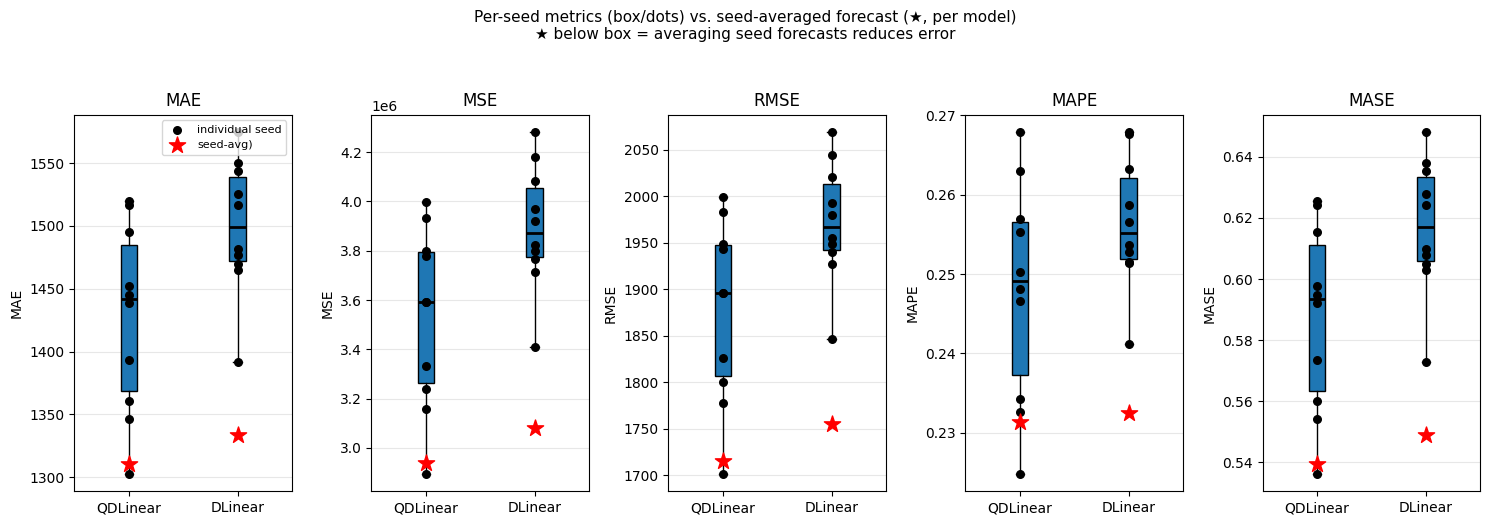


Top 5 Stores (best predicted on average): [794, 772, 208, 558, 656]


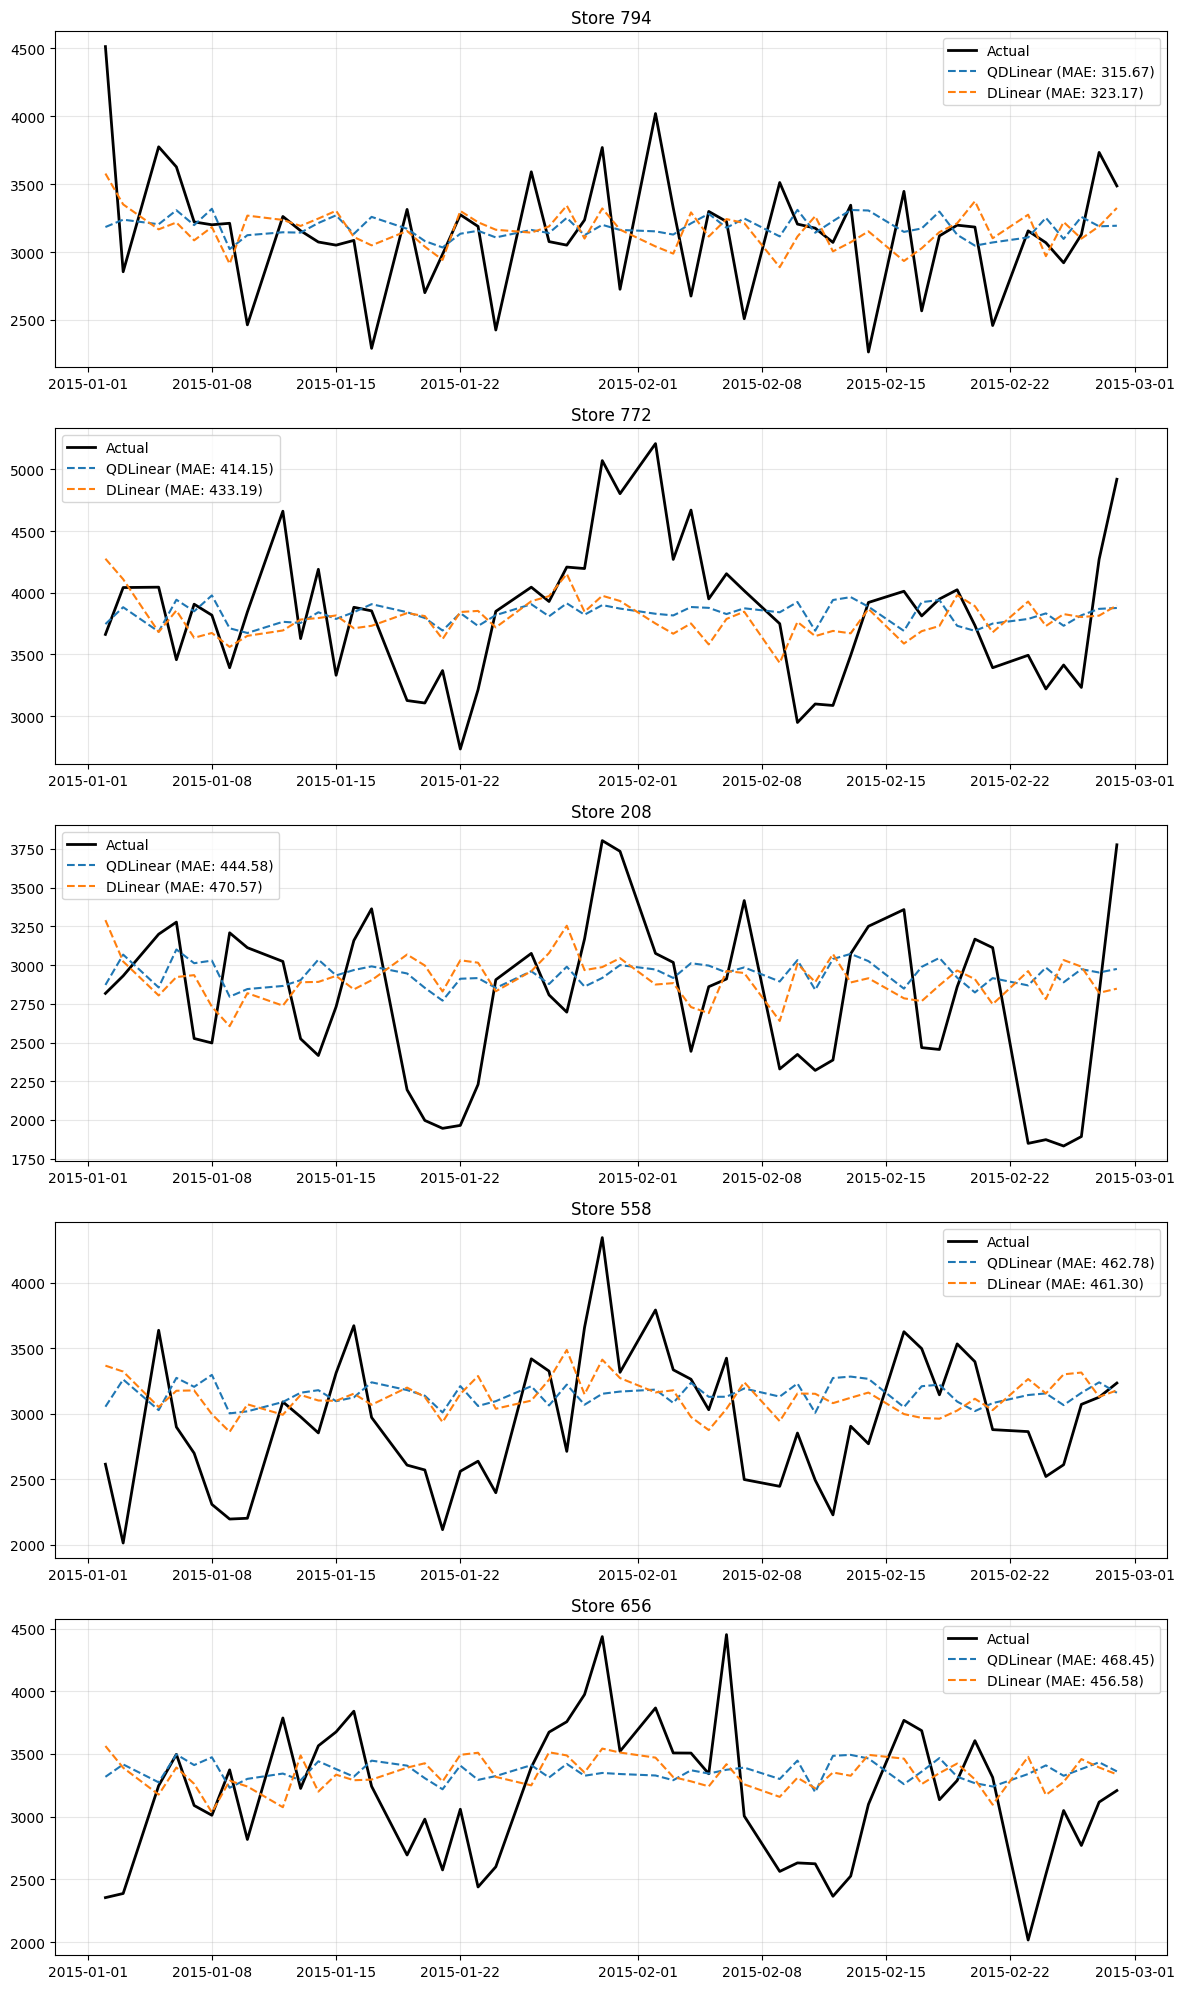

In [ ]:
# --- Average forecasts across seeds ---
model_names = [col for col in seed_forecasts[0].columns if col not in ["index", "Store", "Date"]]

avg_forecasts = seed_forecasts[0][["Store", "Date"]].copy()
for model in model_names:
    avg_forecasts[model] = np.mean(
        [fc[model].values for fc in seed_forecasts], axis=0
    )

print("Forecast date range:", avg_forecasts["Date"].min(), "→", avg_forecasts["Date"].max())
print("Test    date range: ", test_df["Date"].min(), "→", test_df["Date"].max())

comparison = test_df[["Store", "Date", "Sales"]].merge(avg_forecasts, on=["Store", "Date"], how="inner")
print(f"Matched rows after merge: {len(comparison)}")
print(f"Models: {model_names}")

# --- Compute metrics per seed (for std) and on the averaged forecast (reported score) ---
y_train_global = train_df["Sales"].values
SEASONALITY = 7

seed_results = {model: {m: [] for m in ["MAE", "MSE", "RMSE", "MAPE", "MASE"]}
                for model in model_names}

for fc in seed_forecasts:
    comp_seed = test_df[["Store", "Date", "Sales"]].merge(fc, on=["Store", "Date"], how="inner")
    for model in model_names:
        seed_results[model]["MAE"  ].append(mae( comp_seed["Sales"], comp_seed[model]))
        seed_results[model]["MSE"  ].append(mse( comp_seed["Sales"], comp_seed[model]))
        seed_results[model]["RMSE" ].append(rmse(comp_seed["Sales"], comp_seed[model]))
        seed_results[model]["MAPE" ].append(mape(comp_seed["Sales"], comp_seed[model]))
        seed_results[model]["MASE" ].append(mase(comp_seed["Sales"], comp_seed[model],
                                                  y_train=y_train_global, seasonality=SEASONALITY))

avg_results = {}
for model in model_names:
    avg_results[model] = {
        "MAE" : mae( comparison["Sales"], comparison[model]),
        "MSE" : mse( comparison["Sales"], comparison[model]),
        "RMSE": rmse(comparison["Sales"], comparison[model]),
        "MAPE": mape(comparison["Sales"], comparison[model]),
        "MASE": mase(comparison["Sales"], comparison[model],
                     y_train=y_train_global, seasonality=SEASONALITY),
    }

# --- Log to TensorBoard: lightning_logs/test/<ModelName>/ ---
for model in model_names:
    writer = SummaryWriter(log_dir=f"lightning_logs/test/{model}")
    for metric_name, val in avg_results[model].items():
        writer.add_scalar(f"avg_{metric_name}", val, 0)
    for metric_name, vals in seed_results[model].items():
        writer.add_scalar(f"mean_{metric_name}", float(np.mean(vals)), 0)
        writer.add_scalar(f"std_{metric_name}",  float(np.std(vals)),  0)
    writer.close()
    print(f"  [{model}] test metrics logged to TensorBoard.")

# --- Print summary ---
print("\nTest-set metrics (averaged forecast | mean ± std over seeds):")
for model in sorted(avg_results, key=lambda m: avg_results[m]["MAE"]):
    a = avg_results[model]
    s = seed_results[model]
    print(f"\n  {model}:")
    for metric in ["MAE", "MSE", "RMSE", "MAPE", "MASE"]:
        print(f"    {metric}: avg_forecast={a[metric]:.4f}  |  "
              f"seeds={np.mean(s[metric]):.4f} ± {np.std(s[metric]):.4f}")

# --- Box plots: per-seed metric distribution per model ---
# Box  = metric of each individual seed run (3 dots per model)
# ★    = metric after averaging the 3 seed forecasts element-wise BEFORE evaluation
#        (seed ensemble per model — NOT an average across model architectures)
# ★ below box means the seed ensemble is better than any single seed run.
metrics_to_plot = ["MAE", "MSE", "RMSE", "MAPE", "MASE"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 5))
fig.suptitle(
    "Per-seed metrics (box/dots) vs. seed-averaged forecast (★, per model)\n"
    "★ below box = averaging seed forecasts reduces error",
    fontsize=11, y=1.04
)

for ax, metric in zip(axes, metrics_to_plot):
    data = [seed_results[m][metric] for m in model_names]
    ax.boxplot(data, tick_labels=model_names, patch_artist=True, notch=False,
               medianprops=dict(color="black", linewidth=2))
    # Individual seed points
    for i, values in enumerate(data, start=1):
        ax.scatter([i] * len(values), values, color="black", zorder=5, s=30,
                   label="individual seed" if i == 1 else "")
    # Seed-averaged forecast metric (one per model)
    for i, m in enumerate(model_names, start=1):
        ax.scatter(i, avg_results[m][metric], marker="*", color="red",
                   zorder=6, s=150,
                   label=f"seed-avg)" if i == 1 else "")
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(True, axis="y", alpha=0.3)

axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# --- Top 5 best-predicted stores ---
comparison["avg_model_error"] = sum(
    (comparison["Sales"] - comparison[m]).abs() for m in model_names
) / len(model_names)

top_5_stores = (comparison.groupby("Store")["avg_model_error"]
                           .mean().sort_values().head(5).index.tolist())
print(f"\nTop 5 Stores (best predicted on average): {top_5_stores}")

# --- Forecast plot for top 5 stores ---
fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=False)
for i, store_id in enumerate(top_5_stores):
    store_data = comparison[comparison["Store"] == store_id]
    ax = axes[i]
    ax.plot(store_data["Date"], store_data["Sales"], label="Actual", color='black', linewidth=2)
    for model in model_names:
        store_mae = (store_data["Sales"] - store_data[model]).abs().mean()
        ax.plot(store_data["Date"], store_data[model],
                label=f"{model} (MAE: {store_mae:.2f})", linestyle='--')
    ax.set_title(f"Store {store_id}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
